# 다변수 셋팅에서 미분의 직관 이해하기 (뉴진수 8강)-10강 3기 08강

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

x, y, t = sp.symbols("x y t", real=True)

## 3. 전미분: 모든 변수가 함께 변할 때
미분가능한 $F$ 의 1차 변화는 $dF = F_x\,dx + F_y\,dy$. 원 함수 $F=x^2+y^2-1$ 의 편미분을 구하고,
한 점에서 전미분(접평면 1차 근사)이 실제 증분을 잘 맞추는지 확인합니다.

In [2]:
F = x**2 + y**2 - 1
Fx, Fy = sp.diff(F, x), sp.diff(F, y)
print("F  =", F)
print("Fx =", Fx, "   Fy =", Fy)
print("dF = (%s) dx + (%s) dy" % (Fx, Fy))

# linear prediction vs true increment at a base point, for a small step
p = {x: 0.6, y: 0.8}                       # a point on the circle F=0
dx, dy = 0.03, -0.02
dF_lin = float(Fx.subs(p)) * dx + float(Fy.subs(p)) * dy
dF_true = float(F.subs({x: p[x] + dx, y: p[y] + dy}) - F.subs(p))
print("\nat (%.2f, %.2f), step (dx,dy)=(%.2f,%.2f)" % (p[x], p[y], dx, dy))
print("dF linear  = %.6f" % dF_lin)
print("dF true    = %.6f" % dF_true)
print("error      = %.2e  (2nd order, ~ dx^2+dy^2)" % (dF_true - dF_lin))

F  = x**2 + y**2 - 1
Fx = 2*x    Fy = 2*y
dF = (2*x) dx + (2*y) dy

at (0.60, 0.80), step (dx,dy)=(0.03,-0.02)
dF linear  = 0.004000
dF true    = 0.005300
error      = 1.30e-03  (2nd order, ~ dx^2+dy^2)


## 4. 전미분 등식 $dF=0$ 은 어디에서 성립하는가
해집합 $F=0$ 위에서는 $F$ 가 변하지 않으므로 접방향은 $F_x\,dx+F_y\,dy=0$.
$F_y\neq0$ 이면 음함수 도함수 $\dfrac{dy}{dx}=-\dfrac{F_x}{F_y}$. SymPy 음함수 미분으로 검산합니다.

In [3]:
yx = sp.Function("y")(x)
Fimp = x**2 + yx**2 - 1
dydx = sp.solve(sp.Eq(sp.diff(Fimp, x), 0), sp.diff(yx, x))[0]
print("implicit-diff  dy/dx =", dydx)             # -x/y(x)
print("formula  -Fx/Fy      =", sp.simplify(-Fx / Fy))  # -x/y
# numeric check on the upper half circle y = sqrt(1-x^2)
xv = 0.6
slope_formula = float((-Fx / Fy).subs({x: xv, y: np.sqrt(1 - xv**2)}))
yexpr = sp.sqrt(1 - x**2)
slope_direct = float(sp.diff(yexpr, x).subs(x, xv))
print("at x=%.2f:  -Fx/Fy = %.4f ,  d/dx sqrt(1-x^2) = %.4f" % (xv, slope_formula, slope_direct))

implicit-diff  dy/dx = -x/y(x)
formula  -Fx/Fy      = -x/y
at x=0.60:  -Fx/Fy = -0.7500 ,  d/dx sqrt(1-x^2) = -0.7500


## 5. 음함수와 그래디언트의 직교성
레벨셋 $F=0$ 위의 접방향 $d$ 에 대해 $\langle\nabla F, d\rangle = 0$.
원 위 여러 점에서 $\nabla F=(2x,2y)$ 와 접벡터 $(-y,x)$ 의 내적이 $0$ 임을 수치로 확인하고 그림으로 그립니다.

In [4]:
gradF = sp.Matrix([Fx, Fy])
print("grad F =", gradF.T.tolist()[0])
for ang in [0.0, np.pi / 6, np.pi / 3, np.pi / 2, 2 * np.pi / 3]:
    px, py = np.cos(ang), np.sin(ang)
    g = np.array([2 * px, 2 * py])          # gradient at the point
    tang = np.array([-py, px])              # tangent to the circle
    print("  pt=(%+.3f,%+.3f)  grad.tangent = %+.1e" % (px, py, g @ tang))

grad F = [2*x, 2*y]
  pt=(+1.000,+0.000)  grad.tangent = +0.0e+00
  pt=(+0.866,+0.500)  grad.tangent = +0.0e+00
  pt=(+0.500,+0.866)  grad.tangent = +0.0e+00
  pt=(+0.000,+1.000)  grad.tangent = +0.0e+00
  pt=(-0.500,+0.866)  grad.tangent = +0.0e+00


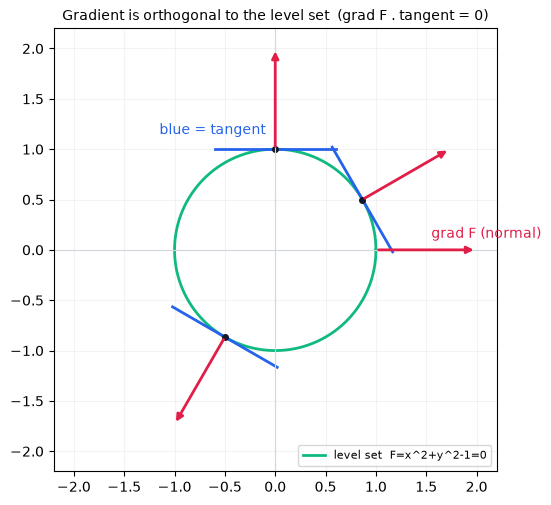

In [5]:
fig, ax = plt.subplots(figsize=(5.6, 5.6))
th = np.linspace(0, 2 * np.pi, 400)
ax.plot(np.cos(th), np.sin(th), color="#10b981", lw=2, label="level set  F=x^2+y^2-1=0")
for ang in [np.pi / 6, np.pi / 2, 4 * np.pi / 3]:
    px, py = np.cos(ang), np.sin(ang)
    g = np.array([px, py])                  # 0.5*grad, drawn shorter
    tg = np.array([-py, px]) * 0.6
    ax.annotate("", xy=(px + g[0], py + g[1]), xytext=(px, py),
                arrowprops=dict(arrowstyle="-|>", color="#e11d48", lw=2))
    ax.plot([px - tg[0], px + tg[0]], [py - tg[1], py + tg[1]], color="#2563eb", lw=2)
    ax.plot(px, py, "o", color="#111827", ms=4)
ax.annotate("", xy=(2.0, 0), xytext=(1.0, 0),
            arrowprops=dict(arrowstyle="-|>", color="#e11d48", lw=2))
ax.text(1.55, 0.12, "grad F (normal)", color="#e11d48", fontsize=10)
ax.text(-1.15, 1.15, "blue = tangent", color="#2563eb", fontsize=10)
ax.set_title("Gradient is orthogonal to the level set  (grad F . tangent = 0)", fontsize=10)
ax.set_xlim(-2.2, 2.2); ax.set_ylim(-2.2, 2.2); ax.set_aspect("equal")
ax.axhline(0, color="#d0d7de", lw=.8); ax.axvline(0, color="#d0d7de", lw=.8)
ax.grid(alpha=.15); ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
plt.show()

## 7. 랭크가 풀이라는 말의 작은 예
"성분이 모두 0이 아니면 풀 랭크"는 틀립니다. $\begin{pmatrix}1&2\\2&4\end{pmatrix}$ 는 둘째 행이 첫째의 2배라 랭크 1,
행렬식은 0. 반면 풀 랭크($2\times2$ 에서 랭크 2)는 행렬식이 0이 아닙니다.

In [6]:
B = sp.Matrix([[1, 2], [2, 4]])
print("B =", B.tolist())
print("  rank(B) =", B.rank(), "   det(B) =", B.det(), "  (rank-deficient: row2 = 2*row1)")
C = sp.Matrix([[1, 2], [3, 4]])
print("C =", C.tolist())
print("  rank(C) =", C.rank(), "   det(C) =", C.det(), "  (full rank)")
# another "all entries nonzero but rank 1" example, as the 생각해볼 점 asks
D = sp.Matrix([[2, 6], [1, 3]])
print("D =", D.tolist(), "  -> rank", D.rank(), ", det", D.det(), " (col2 = 3*col1)")

B = [[1, 2], [2, 4]]
  rank(B) = 1    det(B) = 0   (rank-deficient: row2 = 2*row1)
C = [[1, 2], [3, 4]]
  rank(C) = 2    det(C) = -2   (full rank)
D = [[2, 6], [1, 3]]   -> rank 1 , det 0  (col2 = 3*col1)


## 8. 열방정식: 온도의 그래디언트와 발산
그래디언트는 흐르려는 방향, 발산은 한 점에서 빠져나가는지 모이는지. 가우스 봉우리 온도장
$T=e^{-(x^2+y^2)}$ 에 대해 열흐름 $q=-\nabla T$ 를 만들고 $\nabla\!\cdot q = -\nabla^2 T$ 를 그립니다(라플라시안 부호).

In [7]:
T = sp.exp(-(x**2 + y**2))
gradT = sp.Matrix([sp.diff(T, x), sp.diff(T, y)])
lapT = sp.diff(T, x, 2) + sp.diff(T, y, 2)
divq = sp.simplify(-sp.diff(-sp.diff(T, x), x) - sp.diff(-sp.diff(T, y), y))  # div(-gradT) = -lap T
print("T        =", T)
print("grad T   =", gradT.T.tolist()[0])
print("lap T    =", sp.simplify(lapT))
print("div(q)= -lap T =", sp.simplify(-lapT), "   (hot center: heat leaves -> T drops)")
print("at center (0,0):  -lap T =", float((-lapT).subs({x: 0, y: 0})), "(>0 source-like sign check)")

T        = exp(-x**2 - y**2)
grad T   = [-2*x*exp(-x**2 - y**2), -2*y*exp(-x**2 - y**2)]
lap T    = 4*(x**2 + y**2 - 1)*exp(-x**2 - y**2)
div(q)= -lap T = 4*(-x**2 - y**2 + 1)*exp(-x**2 - y**2)    (hot center: heat leaves -> T drops)
at center (0,0):  -lap T = 4.0 (>0 source-like sign check)


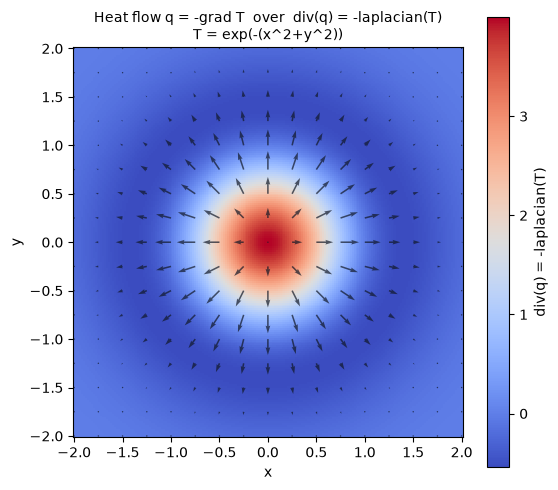

In [8]:
gx = sp.lambdify((x, y), -sp.diff(T, x), "numpy")    # heat flow q = -grad T
gy = sp.lambdify((x, y), -sp.diff(T, y), "numpy")
divf = sp.lambdify((x, y), sp.simplify(-lapT), "numpy")
gr = np.linspace(-2, 2, 200)
XX, YY = np.meshgrid(gr, gr)
fig, ax = plt.subplots(figsize=(5.8, 5.2))
pc = ax.pcolormesh(XX, YY, divf(XX, YY), cmap="coolwarm", shading="auto")
fig.colorbar(pc, ax=ax, label="div(q) = -laplacian(T)")
qg = np.linspace(-2, 2, 17)
QX, QY = np.meshgrid(qg, qg)
ax.quiver(QX, QY, gx(QX, QY), gy(QX, QY), color="#111827", alpha=.7,
          scale=18, width=.004)
ax.set_title("Heat flow q = -grad T  over  div(q) = -laplacian(T)\nT = exp(-(x^2+y^2))", fontsize=10)
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_aspect("equal")
fig.tight_layout()
plt.show()